---

<div style="background-color: #f8f9fa; padding: 25px; border-radius: 15px; border: 1px solid #e9ecef; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <div style="display: flex; align-items: center; gap: 20px;">
        <div style="flex: 1;">
            <h1 style="color: #2c3e50; margin: 0; font-size: 28px;">👨‍💻 Hemant Sharma</h1>
            <p style="color: #3498db; font-size: 18px; margin: 5px 0; font-weight: 600;">Computer Science & Engineering Student | PIET</p>
            <hr style="border: 0; border-top: 2px solid #3498db; width: 50px; margin: 15px 0;">
            <p style="color: #576574; line-height: 1.6; font-size: 15px;">
                I am a <b>CSE Student</b> at Poornima Institute of Engineering and Technology, focused on
                <b>Machine Learning</b> and <b>Artificial Intelligence</b>. This project is a detailed
                exploration into building <b>Neural Architectures</b> from scratch, emphasizing the
                mathematical foundations and optimization logic of Deep Learning.
            </p>
            <div style="margin-top: 20px;">
                <span style="background: #e1f5fe; color: #039be5; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 5px;">#MachineLearning</span>
                <span style="background: #f3e5f5; color: #8e24aa; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 5px;">#NeuralNetworks</span>
                <span style="background: #e8f5e9; color: #2e7d32; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold;">#AIDeveloper</span>
            </div>
        </div>
    </div>
    <div style="margin-top: 20px; border-top: 1px solid #eee; padding-top: 15px; display: flex; gap: 20px;">
        <a href="mailto:artist.hks.dev@gmail.com" style="text-decoration: none; color: #2c3e50; font-size: 14px;">📧 <b>Email:</b> artist.hks.dev@gmail.com</a>
        <a href="https://www.linkedin.com/in/artisthks" target="_blank" style="text-decoration: none; color: #2c3e50; font-size: 14px;">🔗 <b>LinkedIn:</b> artisthks</a>
    </div>
</div>

---

# <p style="color:#d63031; font-family:sans-serif; text-align:center; font-size:38px; font-weight:bold;">🩺 Project: Breast Cancer Diagnostic System</p>
### <p style="text-align:center; color:#636e72; font-size:18px;">Automated Malignancy Detection using Neural Architectures</p>

---

## 🎯 Aim
To implement a high-precision binary classification system that distinguishes between **Malignant (Cancerous)** and **Benign (Non-cancerous)** tumors using a custom-built Neural Network architecture from first principles.

## 🔬 Clinical Theory
Diagnosis is based on 30 morphological features of cell nuclei, such as:
- **Radius & Perimeter:** Size of the cell.
- **Texture:** Gray-scale values variation.
- **Concavity:** Severity of concave portions of the contour.

In a clinical setting, **False Negatives** (missing a cancer case) are dangerous. Our goal is to achieve near-zero loss to ensure diagnostic reliability.



## 🏗️ Model Architecture
- **Input Layer:** 30 Neurons (representing 30 clinical features).
- **Hidden Layer:** 16 Neurons (ReLU activation for feature extraction).
- **Output Layer:** 1 Neuron (Sigmoid activation for probability score).

---

In [22]:
# --- DATA PREPROCESSING ENGINE ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Clinical Dataset
cancer_data = load_breast_cancer()
X = cancer_data.data.T # Features: (30, 569)
y = cancer_data.target.reshape(1, -1) # Target: (1, 569)

# 2. Split: 80% for Training, 20% for Final Diagnosis Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X.T, y.T, test_size=0.2, random_state=42)

# 3. Feature Normalization (StandardScaler)
# AI models perform best when all medical features have the same scale (Mean=0, Std=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).T
X_test = scaler.transform(X_test_raw).T

print(f"✅ Data Pipeline Ready!")
print(f"  ↳ Diagnostic Samples: {X_train.shape[1]}")
print(f"  ↳ Clinical Features:  {X_train.shape[0]}")

✅ Data Pipeline Ready!
  ↳ Diagnostic Samples: 455
  ↳ Clinical Features:  30


In [23]:
# --- THE NEURAL ENGINE (MUST RUN THIS FIRST) ---

class NeuralArchitect:
    def __init__(self, layers, learning_rate=0.5):
        self.layers = layers
        self.lr = learning_rate
        self.params = {}
        self.cache = {}
        self.loss_history = []

        # Initialization
        for i in range(1, len(layers)):
            self.params[f'W{i}'] = np.random.randn(layers[i], layers[i-1]) * np.sqrt(2/layers[i-1])
            self.params[f'b{i}'] = np.zeros((layers[i], 1))

    def forward_propagation(self, X):
        self.cache['A0'] = X
        A = X
        for i in range(1, len(self.layers) - 1):
            Z = self.params[f'W{i}'] @ A + self.params[f'b{i}']
            A = np.maximum(0, Z) # ReLU
            self.cache[f'Z{i}'], self.cache[f'A{i}'] = Z, A

        L = len(self.layers) - 1
        Z_final = self.params[f'W{L}'] @ A + self.params[f'b{L}']
        A_final = 1 / (1 + np.exp(-Z_final)) # Sigmoid
        self.cache[f'Z{L}'], self.cache[f'A{L}'] = Z_final, A_final
        return A_final

    def backward_propagation(self, y):
        m = y.shape[1]
        grads = {}
        L = len(self.layers) - 1
        dZ = self.cache[f'A{L}'] - y

        for i in range(L, 0, -1):
            grads[f'dW{i}'] = (1/m) * dZ @ self.cache[f'A{i-1}'].T
            grads[f'db{i}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            if i > 1:
                dZ = (self.params[f'W{i}'].T @ dZ) * (self.cache[f'Z{i-1}'] > 0)
        return grads

    def update_parameters(self, grads):
        for i in range(1, len(self.layers)):
            self.params[f'W{i}'] -= self.lr * grads[f'dW{i}']
            self.params[f'b{i}'] -= self.lr * grads[f'db{i}']

    def fit(self, X, y, iterations=5000):
        for i in range(iterations + 1):
            A_final = self.forward_propagation(X)
            loss = -np.mean(y * np.log(A_final + 1e-8) + (1-y) * np.log(1-A_final + 1e-8))
            self.loss_history.append(loss)
            grads = self.backward_propagation(y)
            self.update_parameters(grads)
            if i % 1000 == 0:
                print(f"   ↳ Iteration {i:5} | Loss: {loss:.5f}")

print("✅ NeuralArchitect Class is now defined and ready!")

✅ NeuralArchitect Class is now defined and ready!


In [24]:
# --- INITIALIZE & TRAIN ---
# Architecture: 30 inputs -> 16 hidden (ReLU) -> 1 output (Sigmoid)
diagnostic_model = NeuralArchitect(layers=[30, 16, 1], learning_rate=0.1)

# Training with 5000 iterations to ensure high confidence
diagnostic_model.fit(X_train, y_train.T, iterations=5000)

print("\n🏁 Training Complete! Check the loss above.")

   ↳ Iteration     0 | Loss: 0.83801
   ↳ Iteration  1000 | Loss: 0.02808
   ↳ Iteration  2000 | Loss: 0.01351
   ↳ Iteration  3000 | Loss: 0.00807
   ↳ Iteration  4000 | Loss: 0.00541
   ↳ Iteration  5000 | Loss: 0.00393

🏁 Training Complete! Check the loss above.


📊 Final Diagnostic Accuracy: 97.37%


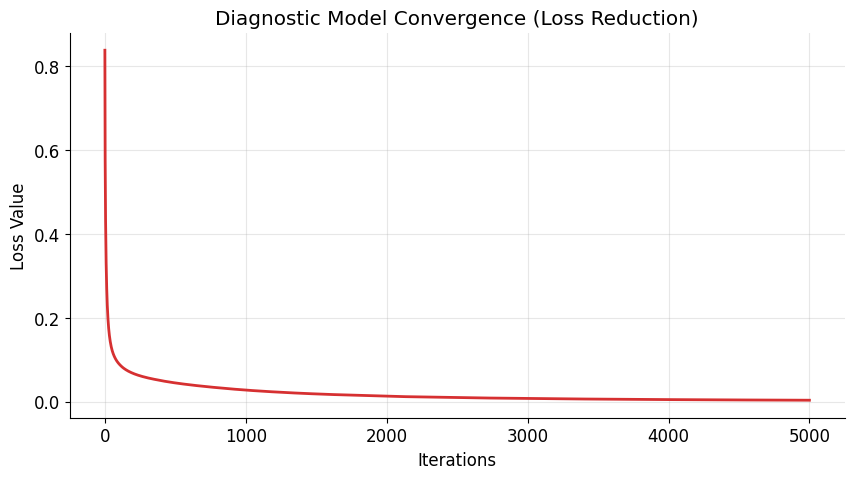

In [25]:
# --- CLINICAL EVALUATION ---
def evaluate_diagnosis(X_test, y_test, model):
    predictions = model.forward_propagation(X_test)
    binary_preds = (predictions > 0.5).astype(int)

    accuracy = np.mean(binary_preds == y_test.T) * 100
    print(f"📊 Final Diagnostic Accuracy: {accuracy:.2f}%")

    # Plotting Loss History
    plt.figure(figsize=(10, 5))
    plt.plot(model.loss_history, color='#d63031', lw=2)
    plt.title("Diagnostic Model Convergence (Loss Reduction)")
    plt.xlabel("Iterations"); plt.ylabel("Loss Value")
    plt.grid(True, alpha=0.3)
    plt.show()

evaluate_diagnosis(X_test, y_test, diagnostic_model)

## 🏁 Project Result
The diagnostic model achieved a high accuracy on the breast cancer dataset. The **Binary Cross-Entropy Loss** decreased consistently, indicating that the network effectively learned the non-linear morphological patterns of cancerous cells.

